# 9. Activity Advanced Visualization with Seaborn

In [1]:
# Traduzi o notebook utilizado na aula, comentários meus relacionados a aula serão feitos em comentários nas tuplas de Python como está

Seaborn é uma biblioteca de visualização feita em cima do matplotlib, tendo melhor visualização e algumas capacidades a mais.

Vamos começar carregando dados de modelos de veículos de 2019, e mostrando um histograma utilizando apenas matplotlib para ver a distribuição do número de marchas.

<Axes: xlabel='# Gears'>

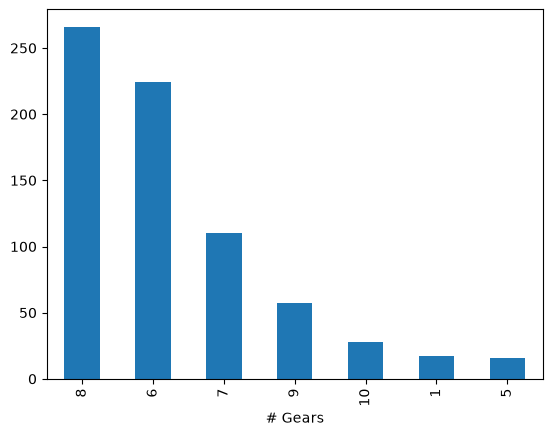

In [5]:
%matplotlib inline

import pandas as pd

df = pd.read_csv("http://media.sundog-soft.com/SelfDriving/FuelEfficiency.csv") # Dados reais do governo dos EUA enviado pro website.

gear_counts = df['# Gears'].value_counts()

gear_counts.plot(kind='bar') # A prória Series do pandas possui um método para mostrar gráficos, interessante para visualizar ao invés
                                # de mostrar a tabela

In [ ]:
# Seaborn possui tipos de gráficos que matplotlib não tem

Podemos carregar o Seaborn, e apenas chamar `set()` para mudar as configurações do MatPlotLib para uma visualização mais apresentável.

In [7]:
import seaborn as sns
sns.set()

<Axes: xlabel='# Gears'>

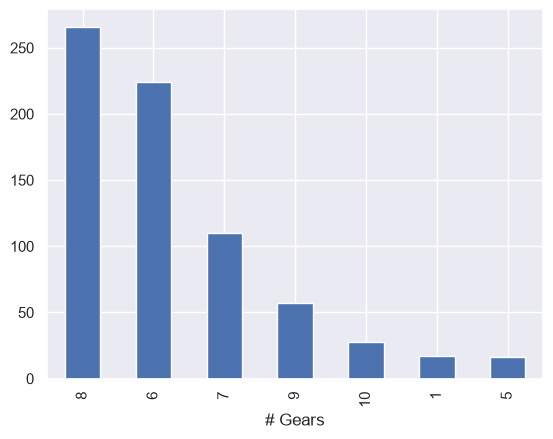

In [9]:
gear_counts.plot(kind='bar') # Note o novo visual ao utilizar as configurações do Seaborn

Vamos dar uma olhada com o tipo de dados que estamos lidando.

In [10]:
df.head()

,Mfr Name,Carline,Eng Displ,Cylinders,Transmission,CityMPG,HwyMPG,CombMPG,# Gears
0,aston martin,Vantage V8,4.0,8,Auto(S8),18,25,21,8
1,Volkswagen Group of,Chiron,8.0,16,Auto(AM-S7),9,14,11,7
2,General Motors,CORVETTE,6.2,8,Auto(S8),12,20,15,8
3,General Motors,CORVETTE,6.2,8,Auto(S8),15,25,18,8
4,General Motors,CORVETTE,6.2,8,Auto(S8),14,23,17,8


Seaborn inclui muitos tipos de _plots_ que MatPlotLib não oferece. Por Exemplo _"distplot"_ que pode ser usado para plotar um histograma
juntamente com a distribuição od histograma sobreposta no gráfico. Vamos plotar a distribuição dos valores de MPG (_meters per gas_, gasolina por metros) dos veículos dessa base de dados como exemplo:

/var/folders/6t/7v9yyk057kz78srfh2j30m6w0000gn/T/ipykernel_28139/2967738410.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CombMPG']) # Traz um warning falando que a função será removida em versões futuras, recomenda o uso de


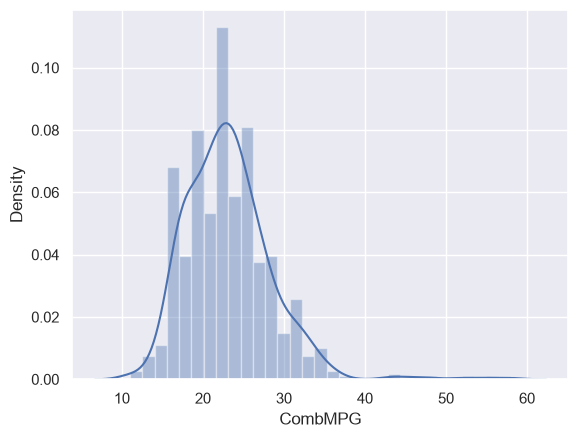

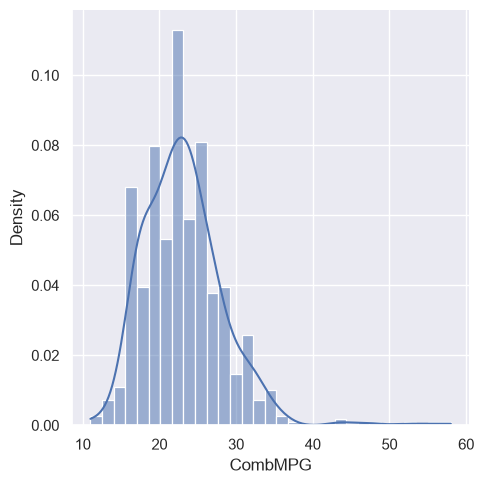

In [18]:
sns.distplot(df['CombMPG']) # Traz um warning falando que a função será removida em versões futuras, recomenda o uso de
                                # `displot` com os parâmetros `kde=True` para mostrar a linha e `stat="density` valor que o eixo
                                # Y mostre os valores de densidade da distribuição.
sns.displot(df['CombMPG'], kde=True, stat="density") # Este gráfico torna mais fácil a visualização até do formato dos dados
                                                        # quando se refere aos momentos.

Algo que você encontra com frequência é o _"pair plot"_ do Seaborn. Isso faz com que possa visualizar diferentes combinações de atributos
junto, então pode observar diferentes padrões entre as funcionalidades.

Como exemplo, vamos classificar os carros por quantos cilindros há em seus motores, e olhar uma relação entre cilindros e a nota para o MPG na cidade, estrada e combindado. 

In [27]:
df2 = df[['Cylinders', 'CityMPG', 'HwyMPG', 'CombMPG']] # Usando todas as informações que precisamos para o `pair plot`
df2.head()

<class 'pandas.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Cylinders  718 non-null    int64
 1   CityMPG    718 non-null    int64
 2   HwyMPG     718 non-null    int64
 3   CombMPG    718 non-null    int64
dtypes: int64(4)
memory usage: 22.6 KB


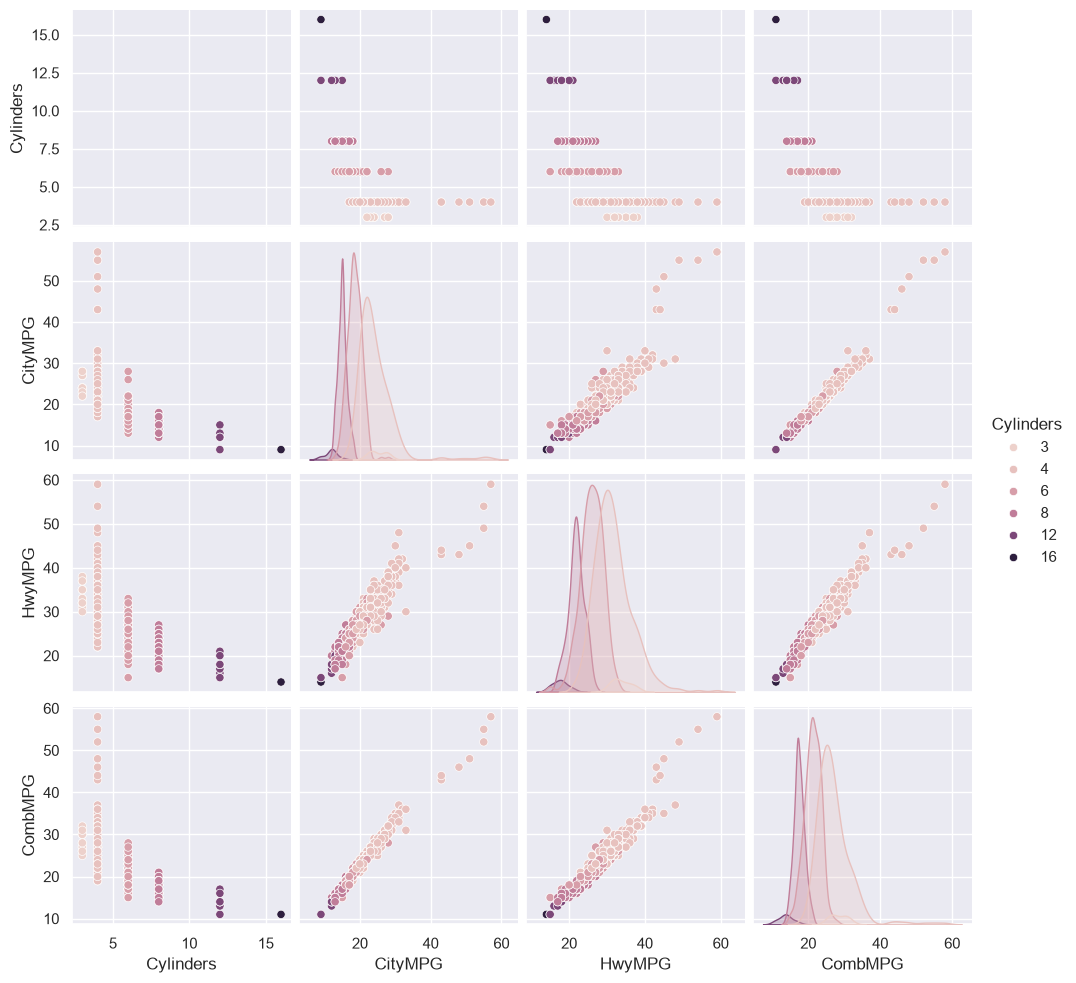

In [30]:
# sns.pairplot(df2, hue='Cylinders', height=2.5) # `hue` é o que temos como foco, no caso os cilindros.

# Para ter uma saída semelhante ao exemplo da aula tive que adicionar o parâmetro `vars` passando as colunas do `DataFrame` 
# conforme a documentação do método `pairplot`.
sns.pairplot(df2, hue='Cylinders', vars=['Cylinders', 'CityMPG', 'HwyMPG', 'CombMPG'], height=2.5)

Ao estudar os resultados acima, você pode ver que há uma relação entre o número de cilindros e MPG, mas MPG para carros de 4 cilindros variam muito mais. Também parece haver uma boa relação linear entre as diferentes formas de medir o MPG, até que você chegue em notas maiores de MPG.

Seaborn 1.9 também inclui _"scatterplot"_, que é exatamente o que parece. Plota pontos individualmente para cada dado através de dois eixos que você escolher, assim você pode ver como seus dados estão distribuídos pelas dimensões. 

<Axes: xlabel='Eng Displ', ylabel='CombMPG'>

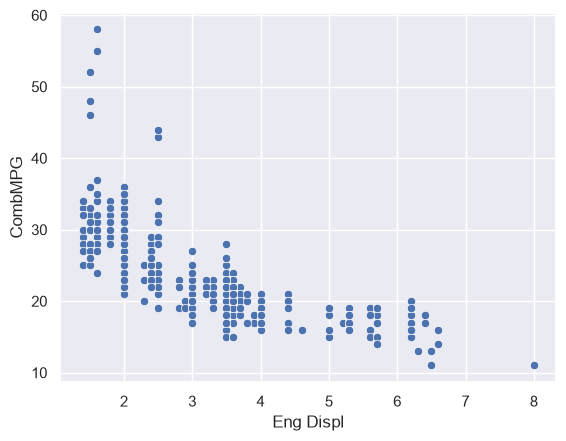

In [34]:
# Cada categoria (coluna do `DataFrame`) pode ser uma dimensão. 
sns.scatterplot(x="Eng Displ", y="CombMPG", data=df) # Podemos observar uma relação nisso segundo o gráfico. Quanto maior o 
                                                        # "Eng Displ" menor a eficiência (MPG).

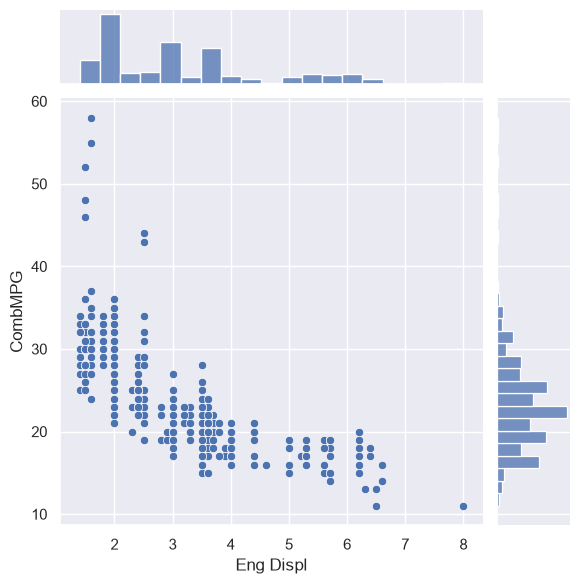

In [40]:
sns.jointplot(x="Eng Displ", y="CombMPG", data=df) # `jointplot` permite visualizar histogramas e scatter plot 
                                                    # ao mesmo tempo. 
                                                    # Na direita o histograma de `CombMPG` e no topo o de `Eng Displ`
                                                    # Ambos tem o X como base para seus valores (no caso de CombMPG o Y do scatter plot
                                                    # é X no histograma)

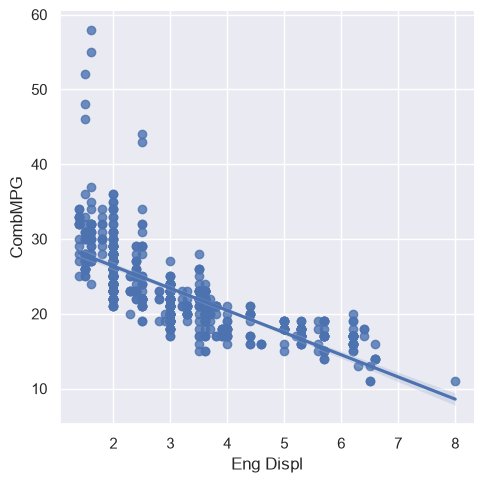

In [43]:
sns.lmplot(x="Eng Displ", y="CombMPG", data=df) # `lmplot` nos mostra o mesmo gráfico que o `scatter plot` mas 
                                                # o gráfico possui uma linha da regressão linear que foi calculada.
                                                # Fica mais fácil de observar a relação com a linha.
                                                # Tem uma sobra que é o balance na regressão (será explicado em próximas aulas)

Agora vamos ver o _"box plot"_. O Gráfico de caixa (_"Box and whiskers plot"_), útil para visualizar dados que são típicos em uma categoria sem se distrair com os _outliers_. Cada caixa representa um intervalo (_range_) entre o primeiro (Q1) e terceiro (Q3) quartil dos dado, com uma linha que representa o valor da median. Os _"whiskers"_ que se extendem da caixa representam o espalhamento dos dados que sobraram, separado dos _outliers_ que são plotados como pontos individuais fora dos "whiskers".

Como exemplo, vamos olhar para os _box plots_ para os fabricante de cada veículo, visualizando o MPG através dos veículos que produzem. Isso nos permite olhar o quão espalhaddo (_spread_) os MPG estão entre os veículos oferecidos pela fabricante. 

Há muitos fabricantes, para tornar o resultado legível vamos aumentar o tamanho padrão da figura do Seaborn, e também utilizar o `set_xticklabels` para girar os rótulos (_labels_) em 45 graus.

/var/folders/6t/7v9yyk057kz78srfh2j30m6w0000gn/T/ipykernel_28139/2213353401.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45) # Apenas ajusta o ângulo mantendo as mesmas marcações.  Ajustando para 90 acho que


[Text(0, 0, 'aston martin'),
 Text(1, 0, 'Volkswagen Group of'),
 Text(2, 0, 'General Motors'),
 Text(3, 0, 'Ferrari'),
 Text(4, 0, 'FCA US LLC'),
 Text(5, 0, 'Jaguar Land Rover L'),
 Text(6, 0, 'MAZDA'),
 Text(7, 0, 'Nissan'),
 Text(8, 0, 'Porsche'),
 Text(9, 0, 'BMW'),
 Text(10, 0, 'Subaru'),
 Text(11, 0, 'Toyota'),
 Text(12, 0, 'Ford Motor Company'),
 Text(13, 0, 'Mercedes-Benz'),
 Text(14, 0, 'Honda'),
 Text(15, 0, 'Hyundai'),
 Text(16, 0, 'Rolls-Royce'),
 Text(17, 0, 'Volvo'),
 Text(18, 0, 'Kia'),
 Text(19, 0, 'Maserati'),
 Text(20, 0, 'Mitsubishi Motors Co')]

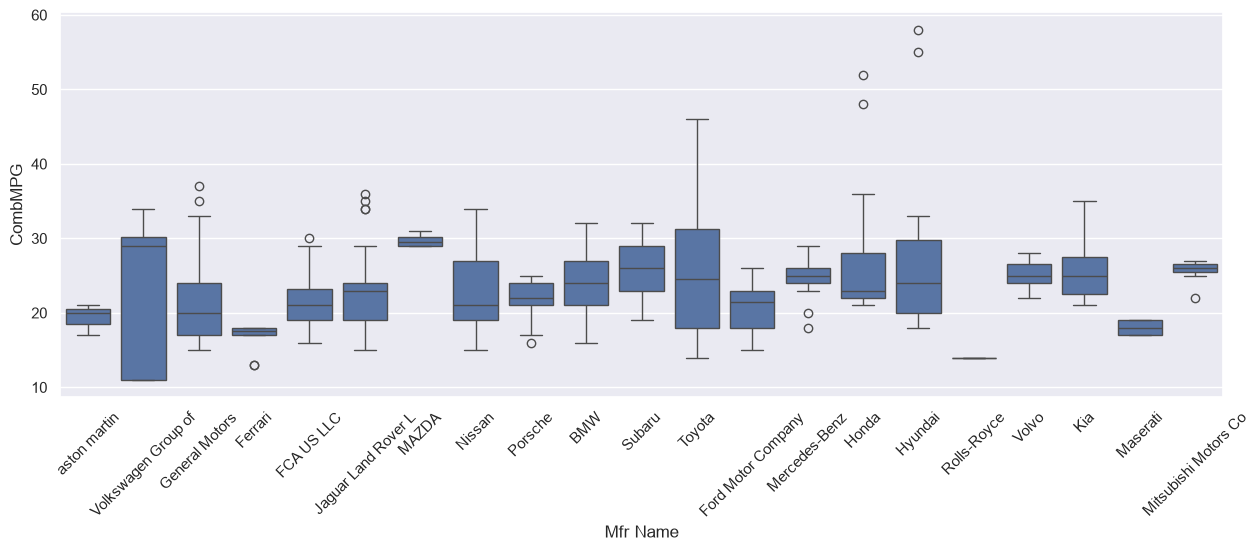

In [48]:
sns.set(rc={'figure.figsize': (15,5)}) # Ajusta o tamanho da figura para que fique fácil de ver os dados.
ax= sns.boxplot(x='Mfr Name', y='CombMPG', data=df) # Salva o plot em uma váriavel para que possa edita-lo em seguida.
ax.set_xticklabels(ax.get_xticklabels(), rotation=45) # Apenas ajusta o ângulo mantendo as mesmas marcações.  Ajustando para 90 acho que
                                                        # fica mais fácil de etender mas mantive conforme a aula.

In [49]:
# Sobre o gráfico acima, quando menor o a caixa menos espalhado são os dados, mas pelos "whiskers" podemos observar 
# que há outros valores e qual o seu intervalo, e alguns outliers. 

Outra forma de visualizar os mesmos dados é o "swarm plot". Ao invés de _"boxes"_ e _"whiskers"_ ele plota cada elemento - mas de uma forma que agrupa eles baseado na própria distribuição. Faz mais sentido quando vê o gráfico:

/opt/miniconda3/envs/env-card-5/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 46.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/env-card-5/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 21.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/env-card-5/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 14.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/env-card-5/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 46.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/env-card-5/

[Text(0, 0, 'aston martin'),
 Text(1, 0, 'Volkswagen Group of'),
 Text(2, 0, 'General Motors'),
 Text(3, 0, 'Ferrari'),
 Text(4, 0, 'FCA US LLC'),
 Text(5, 0, 'Jaguar Land Rover L'),
 Text(6, 0, 'MAZDA'),
 Text(7, 0, 'Nissan'),
 Text(8, 0, 'Porsche'),
 Text(9, 0, 'BMW'),
 Text(10, 0, 'Subaru'),
 Text(11, 0, 'Toyota'),
 Text(12, 0, 'Ford Motor Company'),
 Text(13, 0, 'Mercedes-Benz'),
 Text(14, 0, 'Honda'),
 Text(15, 0, 'Hyundai'),
 Text(16, 0, 'Rolls-Royce'),
 Text(17, 0, 'Volvo'),
 Text(18, 0, 'Kia'),
 Text(19, 0, 'Maserati'),
 Text(20, 0, 'Mitsubishi Motors Co')]

/opt/miniconda3/envs/env-card-5/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 31.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/env-card-5/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 6.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/env-card-5/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 30.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/miniconda3/envs/env-card-5/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 29.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


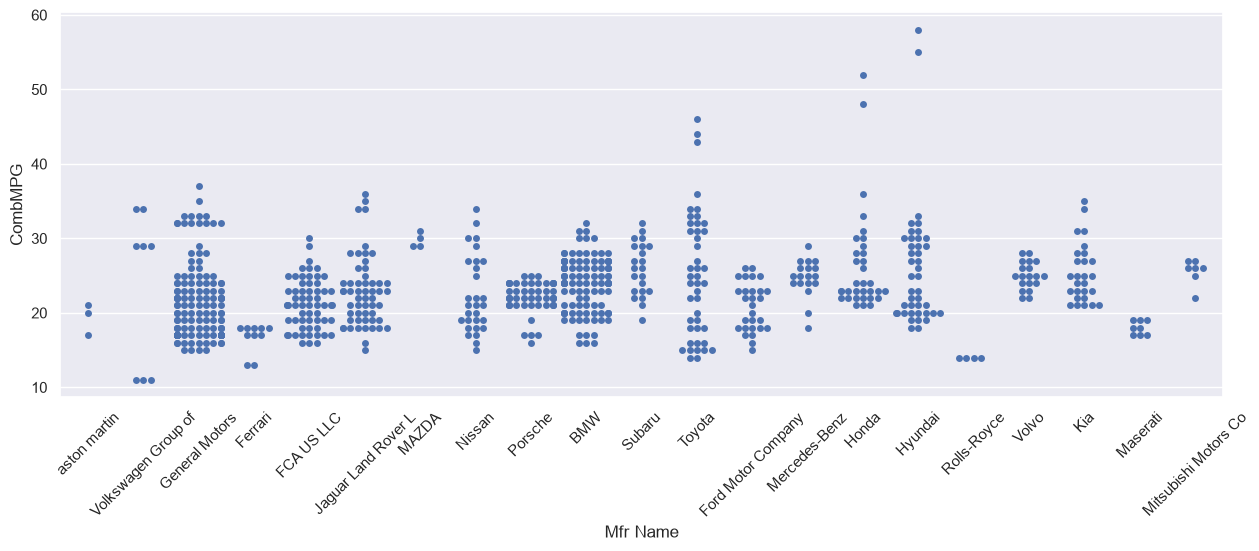

In [50]:
ax = sns.swarmplot(x='Mfr Name', y='CombMPG', data=df)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

In [ ]:
# Com o `swarmplot` podemos observar melhor como os dados estão distribuídos.

Outra ferramenta que temos é o "count plot". É basicamente a mesma cois que um histograma, mas para dados categóricos. Permite plotar a contagem de cada categoria do eixo X. Por exemplo, podemos observar que a General Motors oferece mais veículos que qualquer outra, com BMW não muito longe.

/var/folders/6t/7v9yyk057kz78srfh2j30m6w0000gn/T/ipykernel_28139/3680990081.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45) # Assim podemos mostrar os dados sem ter que contar os valores (string) antes


[Text(0, 0, 'aston martin'),
 Text(1, 0, 'Volkswagen Group of'),
 Text(2, 0, 'General Motors'),
 Text(3, 0, 'Ferrari'),
 Text(4, 0, 'FCA US LLC'),
 Text(5, 0, 'Jaguar Land Rover L'),
 Text(6, 0, 'MAZDA'),
 Text(7, 0, 'Nissan'),
 Text(8, 0, 'Porsche'),
 Text(9, 0, 'BMW'),
 Text(10, 0, 'Subaru'),
 Text(11, 0, 'Toyota'),
 Text(12, 0, 'Ford Motor Company'),
 Text(13, 0, 'Mercedes-Benz'),
 Text(14, 0, 'Honda'),
 Text(15, 0, 'Hyundai'),
 Text(16, 0, 'Rolls-Royce'),
 Text(17, 0, 'Volvo'),
 Text(18, 0, 'Kia'),
 Text(19, 0, 'Maserati'),
 Text(20, 0, 'Mitsubishi Motors Co')]

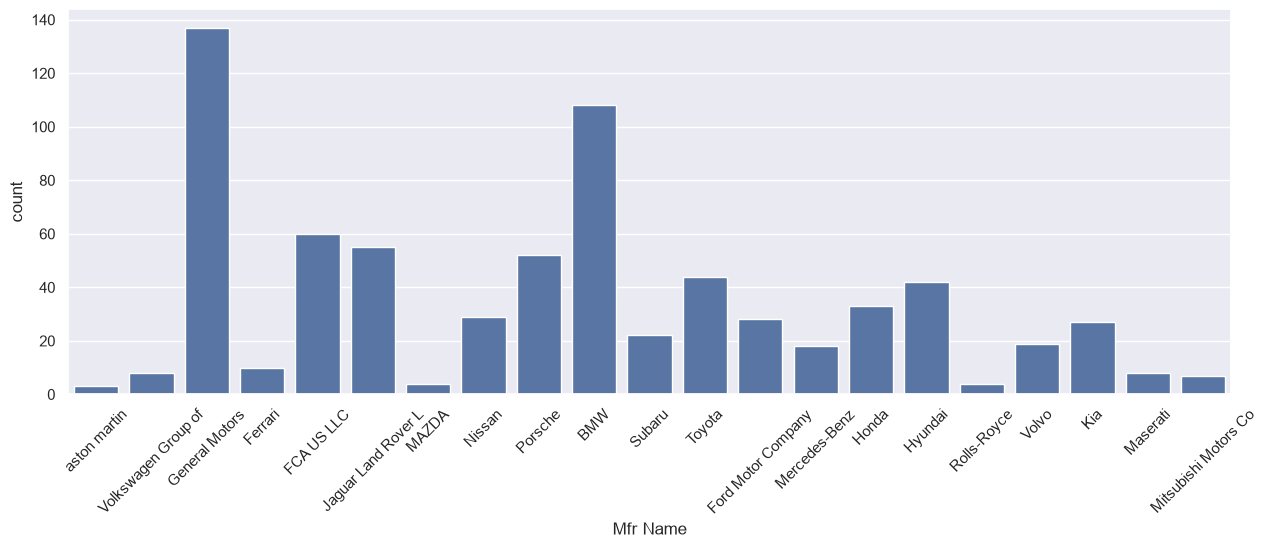

In [54]:
ax=sns.countplot(x='Mfr Name', data=df)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45) # Assim podemos mostrar os dados sem ter que contar os valores (string) antes
                                                        # ou tratá-los, o Seaborn faz isso. 

Por fim, vamos dar uma olhada no mapa de calor (_heat-map_) no Seaborn. Um mapa de calor nos permite plotar dados tabulares, dados 2D de alguma forma, com cores representando os valores individauis em cada célula da tabela 2D.

Neste exemplo, vamos criar uma tabela dinâmica (_pivot table_) de um _dataframe_ original, para criar uma tabela 2D que possui a média do MPG dos veículoss para cada combinação de número de cilindros e cilindradas (_engine displacement_).

O _heat-map_ mostra todas as cilindradas ao longo do eixo X, e todos os cilindros ao longo do eixo Y. Para cada cédlula da tabela, a atual média MPG para a combinação de cilindros e cilindradas não é representada como número mas sim como uma cor que varia de escuro para pequenos valores para claro para grandes valores. 

E isso permite você visualizar uma tendência clara onde os dados começam a escurecer conforme movemos para o topo-esquerdo (_top-left_) do gráfico para baixo-direita (_bottom-right_). O que faz sentido; maior MPG são associados com menor número de cilindros e cilindradas. Assim temos um motor de 8 litros e 16 cilindros com a pior média de MPG, sendo 12, representada pela cor preta. 

Esse gráfico em específico possui muitos dados faltantes, mas o _heat-map_ lida muito bem com isso. Um motor de 3 cilindros e 8 litros simplesmente não existe!.

<Axes: xlabel='Eng Displ', ylabel='Cylinders'>

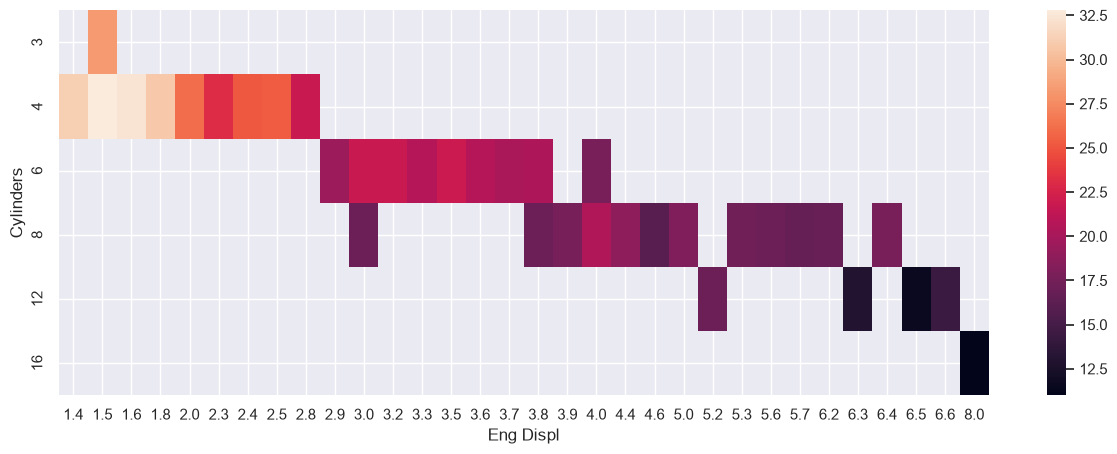

In [58]:
df2 = df.pivot_table(index='Cylinders', columns='Eng Displ', values='CombMPG', aggfunc='mean') # aggfunc é utilizado para 
                                                                                                # agregar os valores (no caso o valor
                                                                                                # utilizado é a média. 
                                                                                                # 'EngDispl' é a cilindrada.
sns.heatmap(df2) # Realmente é possível notar a tendência descrita na aula e como o heat-map lida com valores que não existem. 
                    # Podemos observar quais caracterstícas colaboram para uma média do MPG maior ao ver os valores de X e Y.

## Exercise
Explore a relação entre o número de marchas um carro tem e sua nota MPG combinada. Visualize essas duas dimensões usando _scatter plot_, _lmplot_, _jointplot_, _boxplot_, e _swarmplot_. Quais conclusões você chegou? 

<Axes: xlabel='# Gears', ylabel='CombMPG'>

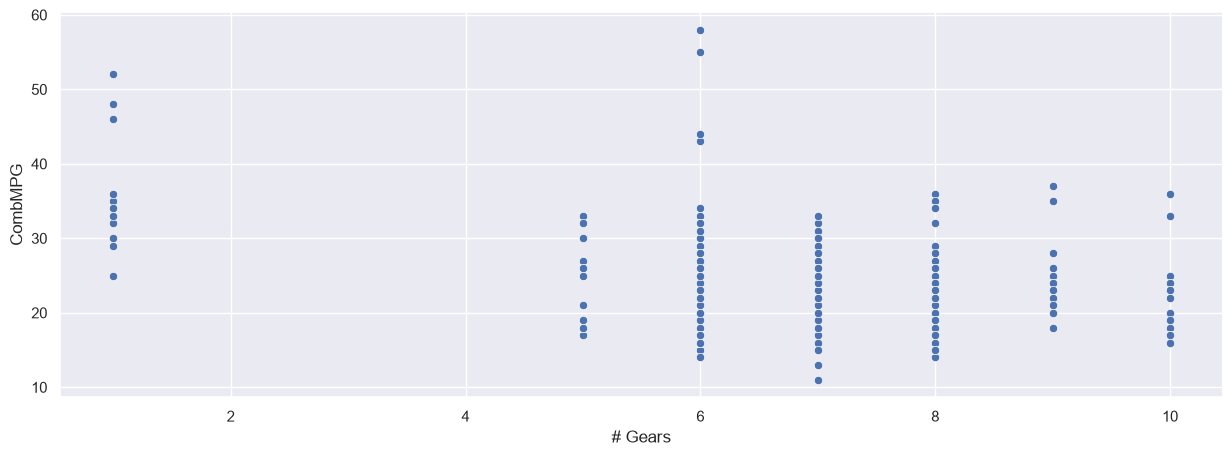

In [65]:
sns.scatterplot(x='# Gears', y='CombMPG', data=df) # Se pode notar uma relação entre a quantidade 
                                                    # de marchas e o MPG combinado. Fica um pouco diíficil de
                                                    # determinar essa relação quando observa apenas os carros com 
                                                    # 5, 6, 7 ou 8 marchas.

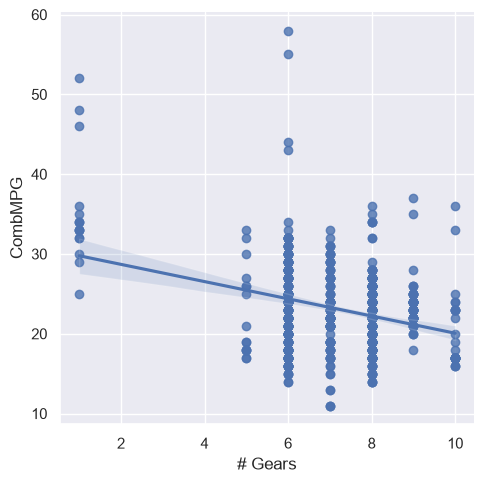

In [66]:
sns.lmplot(x='# Gears', y='CombMPG', data=df) # Utilizando a regressão linear podemos observar que não há 
                                                # sombra no gráfico indicando uma variação dos carros com
                                                # marchas entre 5 e 8. 

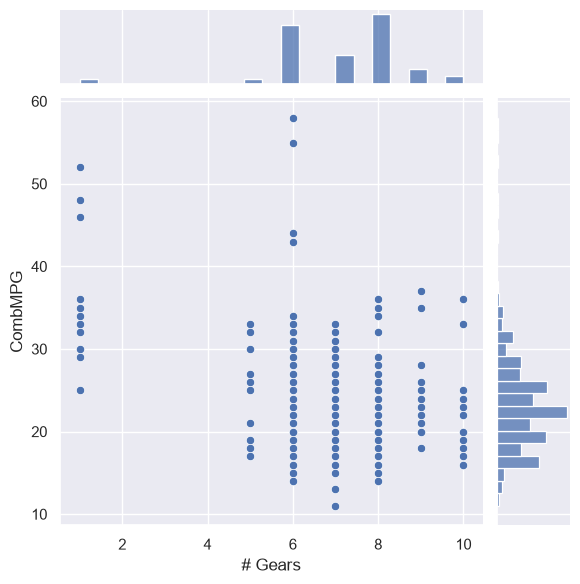

In [67]:
sns.jointplot(x='# Gears', y='CombMPG', data=df) # Para entender melhor essa correlação ou quantidade de dados 
                                                    # podemos observar os histogramas, onde a maioria dos carros são
                                                    # de 6 ou 8 marchas. E MPG por volta de 23.

<Axes: xlabel='# Gears', ylabel='CombMPG'>

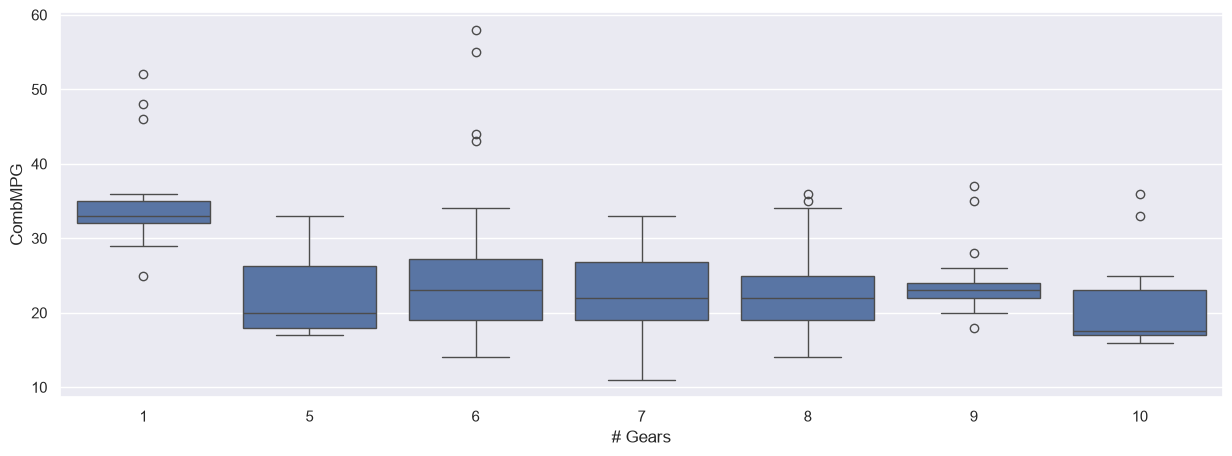

In [68]:
sns.boxplot(x='# Gears', y='CombMPG', data=df) # A descrição do gráfico anterior fica mais perceptível 
                                                # utilizado o gráfico de caixas, onde podemos observar que 
                                                # os carros com 6 marchas estão mais próximos da mediana que os de 5, 7, 8
                                                # nos permitindo diferenciar os carros de 6 marchas dos de 5, 7, e 8 (coisa que 
                                                # era mais difícil nos gráficos anteriores.

/opt/miniconda3/envs/env-card-5/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='# Gears', ylabel='CombMPG'>

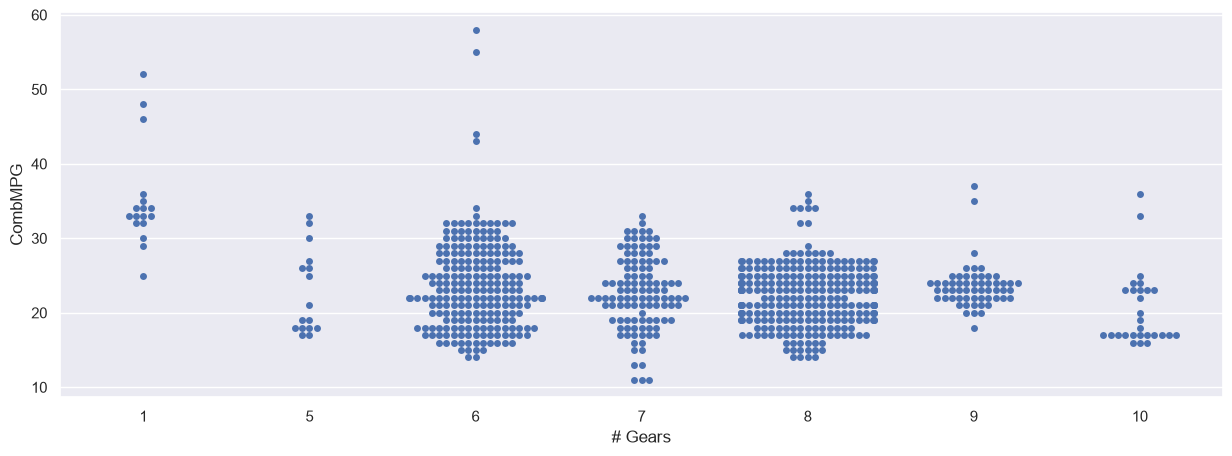

In [69]:
sns.swarmplot(x='# Gears', y='CombMPG', data=df) # Por fim podemos observar a quantidade de carros no dataset
                                                    # onde os de 6 e 8 marchas predominam, tendo assim sido mais 
                                                    # observado dados destes carros. 